# LAB 3 - MÉTODOS NUMÉRICOS - ANTÔNIO VINÍCIUS LIBERATO OLIVEIRA SIEBRA - 610619

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from ISLP.models import (ModelSpec as MS, summarize)

Importação das bibliotecas essenciais para manipulação de dados, visualização, modelagem estatística (statsmodels) e machine learning (sklearn).

In [2]:
df = pd.read_csv('dataset_regressao_limpo.csv')
df.columns = df.columns.str.strip() # Remove espaços extras nos nomes das colunas
df.head()

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DC_POWER
0,25.184316,22.857507,0.0,0.0
1,25.184316,22.857507,0.0,0.0
2,25.184316,22.857507,0.0,0.0
3,25.184316,22.857507,0.0,0.0
4,25.184316,22.857507,0.0,0.0


Carregamento da base `dataset_regressao_limpo.csv` e visualização das primeiras linhas.

**Transformação da Variável Alvo:**
Como a variável `DC_POWER` é contínua, precisamos transformá-la em categórica para aplicar métodos de classificação. Vamos utilizar a **mediana** como ponto de corte. Valores acima da mediana serão classificados como `Positivo` (alta geração) e valores iguais ou abaixo serão `Negativo` (baixa/nenhuma geração).

In [3]:
mediana_power = df['DC_POWER'].median()
df['CLASS_POWER'] = np.where(df['DC_POWER'] > mediana_power, 'Positivo', 'Negativo')
print("Mediana do DC_POWER:", mediana_power)
print(df['CLASS_POWER'].value_counts())

Mediana do DC_POWER: 428.57142855
CLASS_POWER
Negativo    34387
Positivo    34387
Name: count, dtype: int64


Cálculo da matriz de correlação para as variáveis numéricas do dataset, permitindo checar as relações entre as temperaturas, irradiação e a potência gerada.

In [4]:
df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'DC_POWER']].corr()

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DC_POWER
AMBIENT_TEMPERATURE,1.000000,0.855420,0.725278,0.724668
MODULE_TEMPERATURE,0.855420,1.000000,0.961511,0.954811
IRRADIATION,0.725278,0.961511,1.000000,0.989391
DC_POWER,0.724668,0.954811,0.989391,1.000000


Gráfico de dispersão entre a Irradiação e a Potência DC, colorido pelas classes recém-criadas.

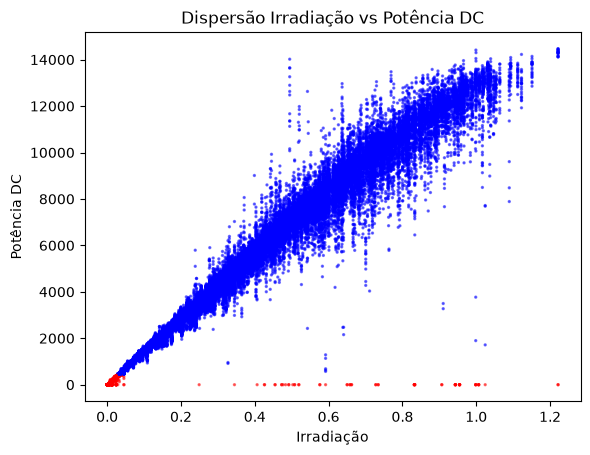

In [5]:
import matplotlib.pyplot as plt
colors = {'Positivo': 'blue', 'Negativo': 'red'}
plt.scatter(df['IRRADIATION'], df['DC_POWER'], c=df['CLASS_POWER'].map(colors), alpha=0.5, s=2)
plt.xlabel('Irradiação')
plt.ylabel('Potência DC')
plt.title('Dispersão Irradiação vs Potência DC')
plt.show()

Configuração da matriz de modelo com os preditores (Temperaturas e Irradiação). Em seguida, treina-se um Modelo Linear Generalizado (GLM) para Regressão Logística (Binomial) a fim de prever se a geração de energia será `Positiva`.

In [6]:
preditores = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
design = MS(preditores)
X = design.fit_transform(df)
y = df['CLASS_POWER'] == 'Positivo'

glm = sm.GLM(y, X, family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,-6.3914,0.265,-24.137,0.000
AMBIENT_TEMPERATURE,-0.0933,0.038,-2.467,0.014
MODULE_TEMPERATURE,0.2252,0.034,6.622,0.000
IRRADIATION,68.5074,1.435,47.725,0.000


Extrai as probabilidades preditas pelo modelo logístico. Classifica como `Positivo` as instâncias com probabilidade > 50% e monta uma matriz de confusão para avaliar a acurácia no próprio dado de treino.

In [7]:
probs = results.predict()
labels = np.array(['Negativo'] * len(df))
labels[probs > 0.5] = 'Positivo'

confusion_matrix(df['CLASS_POWER'], labels)

array([[34323,    64],
       [  903, 33484]])

Cria uma divisão real de treino e teste. O modelo será treinado com 70% dos dados e validado com os 30% restantes para evitar *overfitting* e obter uma taxa de erro realista.

In [8]:
X_train, X_test, y_train_cat, y_test_cat = train_test_split(X, df['CLASS_POWER'], test_size=0.3, random_state=42)
y_train = y_train_cat == 'Positivo'
y_test = y_test_cat == 'Positivo'
X_test.shape

(20633, 4)

Reajusta a regressão logística usando apenas os dados de treino e calcula a matriz de confusão exclusivamente com os dados da base de teste.

In [9]:
glm_train = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results_train = glm_train.fit()
probs_test = results_train.predict(exog=X_test)

labels_test = np.array(['Negativo'] * len(X_test))
labels_test[probs_test > 0.5] = 'Positivo'
confusion_matrix(y_test_cat, labels_test)

array([[10361,    13],
       [  329,  9930]])

Prepara os dados para a biblioteca `scikit-learn` (removendo a coluna de intercepto) e ajusta o modelo de Análise Discriminante Linear (LDA). Exibe as médias das variáveis para cada classe.

In [10]:
X_train_drop = X_train.drop(columns=['intercept'])
X_test_drop = X_test.drop(columns=['intercept'])

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(store_covariance=True)
lda.fit(X_train_drop, y_train_cat)
lda.means_

array([[2.33084026e+01, 2.15933938e+01, 2.68214130e-03],
       [2.78012392e+01, 4.09024993e+01, 4.62436547e-01]])

Gera predições usando o modelo LDA no conjunto de teste e exibe a matriz de confusão.

In [11]:
lda_pred = lda.predict(X_test_drop)
confusion_matrix(y_test_cat, lda_pred)

array([[10361,    13],
       [ 2326,  7933]])

Ajusta e prevê usando Análise Discriminante Quadrática (QDA). Este modelo lida com covariâncias separadas para cada classe, sendo mais flexível do que o LDA.

In [12]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
qda = QDA(store_covariance=True)
qda.fit(X_train_drop, y_train_cat)
qda_pred = qda.predict(X_test_drop)
confusion_matrix(y_test_cat, qda_pred)

array([[10265,   109],
       [  710,  9549]])

Ajusta um modelo Naive Bayes, que assume que todos os preditores são independentes entre si dentro de cada classe, e exibe a performance via matriz de confusão.

In [13]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train_drop, y_train_cat)
nb_pred = nb.predict(X_test_drop)
confusion_matrix(y_test_cat, nb_pred)

array([[10147,   227],
       [  853,  9406]])

Aplica o algoritmo de K-Vizinhos Mais Próximos (KNN) com K=1. Como é um modelo não-paramétrico, a predição é baseada puramente na observação mais próxima da amostra. 

*Nota: O KNN requer padronização dos dados para funcionar bem, pois é baseado em distâncias. Faremos isso aqui com StandardScaler.*

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier as KNN

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_drop)
X_test_std = scaler.transform(X_test_drop)

knn1 = KNN(n_neighbors=1)
knn1.fit(X_train_std, y_train_cat)
knn1_pred = knn1.predict(X_test_std)
confusion_matrix(y_test_cat, knn1_pred)

array([[10348,    26],
       [   54, 10205]])

Refaz o KNN com K=3, reduzindo a variabilidade extrema ao usar o consenso dos 3 vizinhos mais próximos para a classificação.

In [15]:
knn3 = KNN(n_neighbors=3)
knn3.fit(X_train_std, y_train_cat)
knn3_pred = knn3.predict(X_test_std)
confusion_matrix(y_test_cat, knn3_pred)

array([[10348,    26],
       [   26, 10233]])